Total number of images (X): 1797
Total number of labels (Y): 1797
SVM training completed.
Model Accuracy: 0.8166666666666667


Saving sample_data(21).png to sample_data(21).png


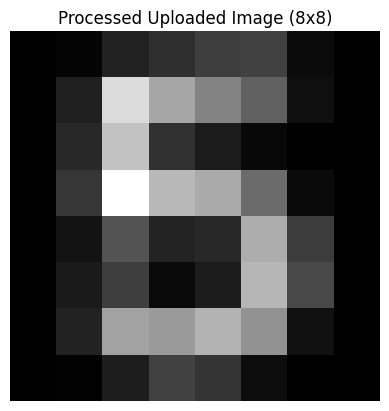

Predicted Digit: 9


In [ ]:
# Classical ML based Digit Recognition using HOG + SVM (ALL-IN-ONE)

import numpy as np
import matplotlib.pyplot as plt
import cv2

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

from skimage.feature import hog
from skimage.transform import resize

from google.colab import files

# LOAD DATASET
digits = datasets.load_digits()

X = digits.images
y = digits.target

print("Total number of images (X):", X.shape[0])
print("Total number of labels (Y):", y.shape[0])


# HOG FEATURE EXTRACTION
features = []

for img in X:
    hog_feature = hog(
        img,
        pixels_per_cell=(4, 4),
        cells_per_block=(1, 1),
        orientations=9
    )
    features.append(hog_feature)

features = np.array(features)


# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    features, y, test_size=0.2, random_state=42
)


# TRAIN SVM MODEL
model = SVC(kernel='linear')
model.fit(X_train, y_train)

print("SVM training completed.")


# MODEL EVALUATION
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)


# UPLOAD IMAGE
uploaded = files.upload()

for file_name in uploaded.keys():
    img = cv2.imread(file_name)

# IMAGE PREPROCESSING
if len(img.shape) == 3:
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
else:
    img_gray = img

img_resized = resize(img_gray, (8, 8), anti_aliasing=True)

img_resized = img_resized / img_resized.max()

img_resized = 1 - img_resized

# DISPLAY PROCESSED IMAGE

plt.imshow(img_resized, cmap='gray')
plt.title("Processed Uploaded Image (8x8)")
plt.axis('off')
plt.show()

# PREDICTION
test_feature = hog(
    img_resized,
    pixels_per_cell=(4, 4),
    cells_per_block=(1, 1),
    orientations=9
)

prediction = model.predict([test_feature])

print("Predicted Digit:", prediction[0])

Loading saved model...


Saving sample_data(21).png to sample_data(21) (2).png


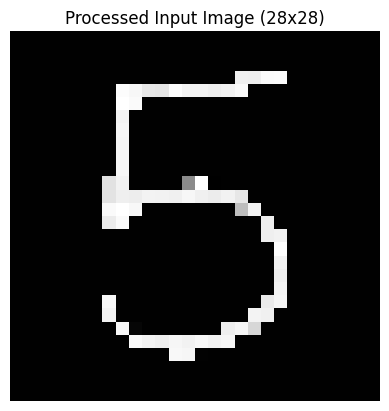

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Predicted Digit: 5
Confidence: 99.99 %


In [ ]:
# CNN-based Digit Recognition

import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

from google.colab import files

MODEL_PATH = "digit_cnn_model.h5"

# 1. LOAD / TRAIN MODEL
if not os.path.exists(MODEL_PATH):

    print("Training model for the first time...")

    # LOAD MNIST DATASET
    (X_train, y_train), (X_test, y_test) = mnist.load_data()

    # Normalize
    X_train = X_train / 255.0
    X_test = X_test / 255.0

    # Reshape for CNN
    X_train = X_train.reshape(-1, 28, 28, 1)
    X_test = X_test.reshape(-1, 28, 28, 1)

    # One-hot encode labels
    y_train = to_categorical(y_train)
    y_test = to_categorical(y_test)

    print("Training samples:", X_train.shape)
    print("Testing samples:", X_test.shape)

    # BUILD CNN MODEL
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        MaxPooling2D((2,2)),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D((2,2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.summary()

    # TRAIN MODEL
    model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=128,
        validation_split=0.1
    )

    # EVALUATE
    loss, accuracy = model.evaluate(X_test, y_test)
    print("Test Accuracy:", accuracy)

    # SAVE MODEL
    model.save(MODEL_PATH)
    print("Model saved successfully.")

else:
    print("Loading saved model...")
    model = load_model(MODEL_PATH)

# 2. UPLOAD IMAGE FOR PREDICTION
uploaded = files.upload()

for file_name in uploaded.keys():
    img = cv2.imread(file_name)

# 3. PREPROCESS IMAGE
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

img_resized = cv2.resize(img_gray, (28,28))
img_resized = img_resized / 255.0
img_resized = 1 - img_resized

img_input = img_resized.reshape(1,28,28,1)

# DISPLAY IMAGE
plt.imshow(img_resized, cmap='gray')
plt.title("Processed Input Image (28x28)")
plt.axis('off')
plt.show()

# 4. PREDICTION
prediction = model.predict(img_input)
predicted_digit = np.argmax(prediction)
confidence = np.max(prediction)

print("Predicted Digit:", predicted_digit)
print("Confidence:", round(confidence*100, 2), "%")
